<div style="background:#C1ABA6">
<div style="font-size: xx-large ; font-weight: 900 ;  padding-top: 100px ; color: rgba(0 , 0 , 0 , 0.8); line-height: 100%"; align="center">Seizmičke postaje i metapodaci</div>
    
---
<div align="center"> Vježbe iz Seizmologije I </div>
<div align="center"> ak. god. 2026./2027. </div>
<div align="center"> dr.sc. Katarina Zailac </div>

---
</div>

# [FDSN StationXML](https://www.fdsn.org/xml/station/)

StationXML je [XML](https://en.wikipedia.org/wiki/XML) koji sadrži meta-podatke za opisivanje prikupljenih geofizičkih podataka.

Primjer jednog takvog dokumenta:

```xml
<?xml version="1.0" encoding="UTF-8"?>
<FDSNStationXML xmlns="http://www.fdsn.org/xml/station/1"
    xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance"
    xsi:schemaLocation="http://www.fdsn.org/xml/station/1 http://www.fdsn.org/xml/station/fdsn-station-1.2.xsd"
    schemaVersion="1.2">
  <Source></Source>
  <Sender>FAKE-DC</Sender>
  <Module>Some WEB SERVICE</Module>
  <Created>2022-02-21T20:27:54.6270Z</Created>
  <Network code="IU" startDate="1988-01-01T00:00:00Z">
   <Description>Global Seismograph Network - IRIS/USGS (GSN)</Description>
   <Identifier type="DOI">10.7914/SN/IU
   </Identifier>
   <Station code="ANMO" startDate="2002-11-19T21:07:00Z">
    <Description>(GSN) IRIS/USGS (IU) and ANSS</Description>
    <Latitude>34.94591</Latitude>
    <Longitude>-106.4572</Longitude>
    <Elevation>1820.0</Elevation>
    <Site>
     <Name>Albuquerque, New Mexico, USA</Name>
    </Site>
    <Channel code="BHZ" locationCode="00" startDate="2018-07-09T20:45:00Z" >
     <Latitude>34.94591</Latitude>
     <Longitude>-106.4572</Longitude>
     <Elevation>1632.7</Elevation>
     <Depth>188</Depth>
     <Azimuth>0</Azimuth>
     <Dip>-90</Dip>
     <SampleRate>40</SampleRate>
     <Sensor>
      <Description>Streckeisen STS-6A VBB Seismometer</Description>
     </Sensor>
     <Response>
     <InstrumentSensitivity>
       <Value>1.98475E9</Value>
       <Frequency>0.02</Frequency>
       <InputUnits>
         <Name>m/s</Name>
       </InputUnits>
       <OutputUnits>
         <Name>count</Name>
       </OutputUnits>
     </InstrumentSensitivity>
     </Response>
    </Channel>
   </Station>
  </Network>
 </FDSNStationXML>
```

Primijetite kako svaki XML element mora imati početni (npr. `<Station>`) i završni (npr. `</Station>`) tag te se mora poštivati hijerarhija definirana u standardu (npr. `<Channel>` ne može postojati izvan elementa `<Station>` i sl.).

Knjižnica [ObsPy](https://docs.obspy.org/) ima funkciju [`read_inventory()`](https://docs.obspy.org/packages/autogen/obspy.core.inventory.inventory.read_inventory.html) koja može čitati tako definirane meta-podatke.

In [1]:
from obspy import read_inventory

inventory = read_inventory("./data/station_KALN.xml", format="STATIONXML")
print(type(inventory))

<class 'obspy.core.inventory.inventory.Inventory'>


Struktura objekta [`Inventory`](https://docs.obspy.org/packages/autogen/obspy.core.inventory.inventory.Inventory.html) je usko vezana uz definiciju [FDSN StationXML-a](https://www.fdsn.org/xml/station/).

![Struktura objekta Inventory](https://docs.obspy.org/_images/Inventory.png)

Možemo pogledati kako izgleda priložena StationXML datoteka. 

Ako na početku ćelije stavimo `!`, onda možemo koristiti BASH naredbe kako bismo ih koristili i direktno u terminalu.

Naredba [`head`](https://www.w3schools.com/bash/bash_head.php) će ispisati početak datoteke koja je dana kao argument naredbe. Ako nije zadano drugačije, naredba će ispisati prvih 10 redaka zadane datoteke.

In [2]:
!head ./data/station_KALN.xml

<?xml version='1.0' encoding='UTF-8'?>
<FDSNStationXML xmlns="http://www.fdsn.org/xml/station/1" schemaVersion="1.2">
  <Source>PMF GFO</Source>
  <Module>ObsPy 1.4.2</Module>
  <ModuleURI>https://www.obspy.org</ModuleURI>
  <Created>2026-06-30T09:29:46.857135Z</Created>
  <Network code="CR" startDate="2001-04-10T00:00:00.000000Z">
    <Description>CROSSNET NETWORK</Description>
    <Station code="KALN" startDate="2006-01-01T00:00:00.000000Z" restrictedStatus="open">
      <Latitude unit="DEGREES">46.131168</Latitude>


# Informacije o StationXML-u

Korištenjem Python naredbe `print` na objektu [`Inventory`](https://docs.obspy.org/packages/autogen/obspy.core.inventory.inventory.Inventory.html), možemo dobiti osnovne informacije.

In [3]:
print(inventory)

Inventory created at 2026-06-30T09:29:46.857135Z
	Created by: ObsPy 1.4.2
		    https://www.obspy.org
	Sending institution: PMF GFO
	Contains:
		Networks (1):
			CR
		Stations (1):
			CR.KALN (Kalnik, Croatia)
		Channels (6):
			CR.KALN..BHZ, CR.KALN..BHN, CR.KALN..BHE, CR.KALN..HLZ, 
			CR.KALN..HLN, CR.KALN..HLE


Elemente objekta [`Inventory`](https://docs.obspy.org/packages/autogen/obspy.core.inventory.inventory.Inventory.html) možemo tretirati kao i bilo koji drugi iterable objekt u Pythonu. 

Tako možemo iterirati kroz objekte i referencirati ih indeksom. Elementi objekta [`Inventory`](https://docs.obspy.org/packages/autogen/obspy.core.inventory.inventory.Inventory.html) su mreže. Tako pojedinoj mreži možemo pristupati ili iteriranjem kroz elemente objekta [`Inventory`](https://docs.obspy.org/packages/autogen/obspy.core.inventory.inventory.Inventory.html), ili indeksiranjem. U našem primjeru imamo samo jednu mrežu u objektu [`Inventory`](https://docs.obspy.org/packages/autogen/obspy.core.inventory.inventory.Inventory.html).

In [4]:
network = inventory[0]

print(network)

Network CR (CROSSNET NETWORK)
	Station Count: None/None (Selected/Total)
	2001-04-10T00:00:00.000000Z - --
	Access: UNKNOWN
	Contains:
		Stations (1):
			CR.KALN (Kalnik, Croatia)
		Channels (6):
			CR.KALN..BHZ, CR.KALN..BHN, CR.KALN..BHE, CR.KALN..HLZ, 
			CR.KALN..HLN, CR.KALN..HLE


Analogno vrijedi i za postaje...

In [5]:
station = network[0]

print(station)

Station KALN (Kalnik, Croatia)
	Station Code: KALN
	Channel Count: None/None (Selected/Total)
	2006-01-01T00:00:00.000000Z - 
	Access: open 
	Latitude: 46.1312, Longitude: 16.4555, Elevation: 583.0 m
	Available Channels:
	    ..HL[ZNE]   100.0 Hz  2006-01-01 to None
	    ..BH[ZNE]    50.0 Hz  2006-01-01 to None



... i za kanale.

In [6]:
channel = station[0]

print(channel)

Channel 'BHE', Location '' 
	Time range: 2006-01-01T00:00:00.000000Z - --
	Latitude: 46.1312, Longitude: 16.4555, Elevation: 583.0 m, Local Depth: 0.0 m
	Azimuth: 90.00 degrees from north, clockwise
	Dip: 0.00 degrees down from horizontal
	Sampling Rate: 50.00 Hz
	Sensor (Description): None (CMG-40T, 30s-100Hz, 1600 V/m/s-DM-24 Mk3 Fixed Gai)
	Response information available


U elementima tipa [`Channel`](https://docs.obspy.org/packages/autogen/obspy.core.inventory.channel.Channel.html) je definiran i odziv instrumenta. Njega možemo dekonvoluirati sa zapisom, kako bismo dobili seizmogram u **realnim jedinicama** (u slučaju *broadband* instrumenata, to će biti m/s).

In [7]:
print(channel.response)

Channel Response
	From M/S (None) to COUNTS (None)
	Overall Sensitivity: 6.27451e+08 defined at 0.100 Hz
	10 stages:
		Stage 1: PolesZerosResponseStage from M/S to V, gain: 800
		Stage 2: CoefficientsTypeResponseStage from V to COUNTS, gain: 784314
		Stage 3: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 4: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 5: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 6: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 7: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 8: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 9: FIRResponseStage from COUNTS to COUNTS, gain: 1
		Stage 10: FIRResponseStage from COUNTS to COUNTS, gain: 1


# Lokacije seizmičkih postaja

Za brzi pregled lokacija seizmičkih postaja unutar objekta [`Inventory`](https://docs.obspy.org/packages/autogen/obspy.core.inventory.inventory.Inventory.html) možemo koristiti funkciju [`plot()`](https://docs.obspy.org/packages/autogen/obspy.core.inventory.inventory.Inventory.plot.html#obspy.core.inventory.inventory.Inventory.plot).

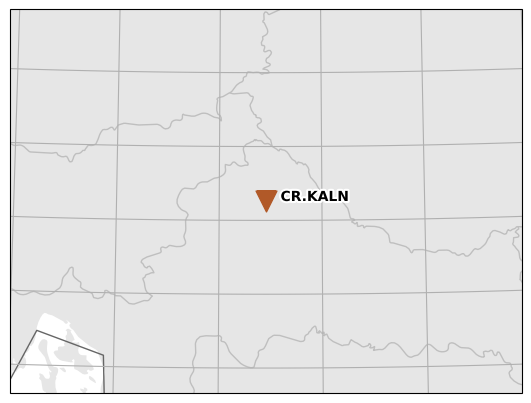

In [8]:
inventory.plot("local");

U slučaju da nešto želimo učiniti s informacijama o koordinatama postaja (odnosno kanala, jer su koordinate spremljene u objektu tipa [`Channel`](https://docs.obspy.org/packages/autogen/obspy.core.inventory.channel.Channel.html#obspy.core.inventory.channel.Channel)), možemo ih jednostavno dobiti korištenjem funkcije [`get_coordinates()`](https://docs.obspy.org/packages/autogen/obspy.core.inventory.inventory.Inventory.get_coordinates.html#obspy.core.inventory.inventory.Inventory.get_coordinates).

In [9]:
coords = inventory.get_coordinates("CR.KALN..BHZ")
print(coords)

{'latitude': 46.131168, 'longitude': 16.455451, 'elevation': 583.0, 'local_depth': 0.0}


# Dekonvolucija odziva instrumenta

Učitajmo zapis zagrebačkog potresa zabilježenog na postaji KALN.

In [10]:
from obspy import read

st = read("./data/waveform_KALN.mseed")

print(st)

3 Trace(s) in Stream:
CR.KALN..BHE | 2020-03-22T05:00:00.000000Z - 2020-03-22T06:00:00.000000Z | 50.0 Hz, 180001 samples
CR.KALN..BHN | 2020-03-22T05:00:00.000000Z - 2020-03-22T06:00:00.000000Z | 50.0 Hz, 180001 samples
CR.KALN..BHZ | 2020-03-22T05:00:00.000000Z - 2020-03-22T06:00:00.000000Z | 50.0 Hz, 180001 samples


In [11]:
print(st[0].stats)

         network: CR
         station: KALN
        location: 
         channel: BHE
       starttime: 2020-03-22T05:00:00.000000Z
         endtime: 2020-03-22T06:00:00.000000Z
   sampling_rate: 50.0
           delta: 0.02
            npts: 180001
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'D', 'number_of_records': 52, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 4096, 'filesize': 606208})


Kopirat ćemo originalni zapis u novu varijablu, te ćemo koristiti funkciju [`remove_response()`](https://docs.obspy.org/packages/autogen/obspy.core.stream.Stream.remove_response.html) kako bismo dobili seizmogram u m/s.

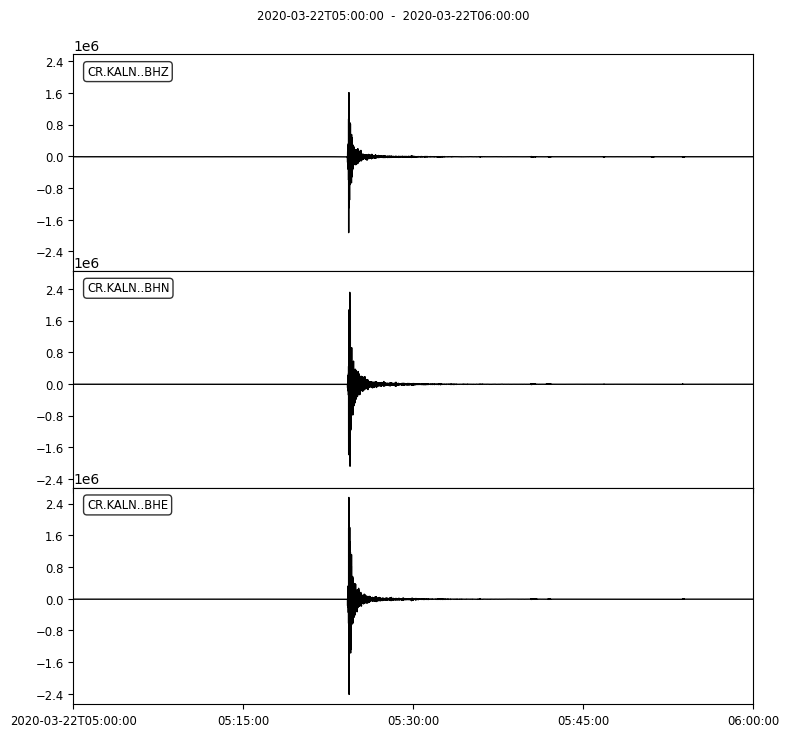

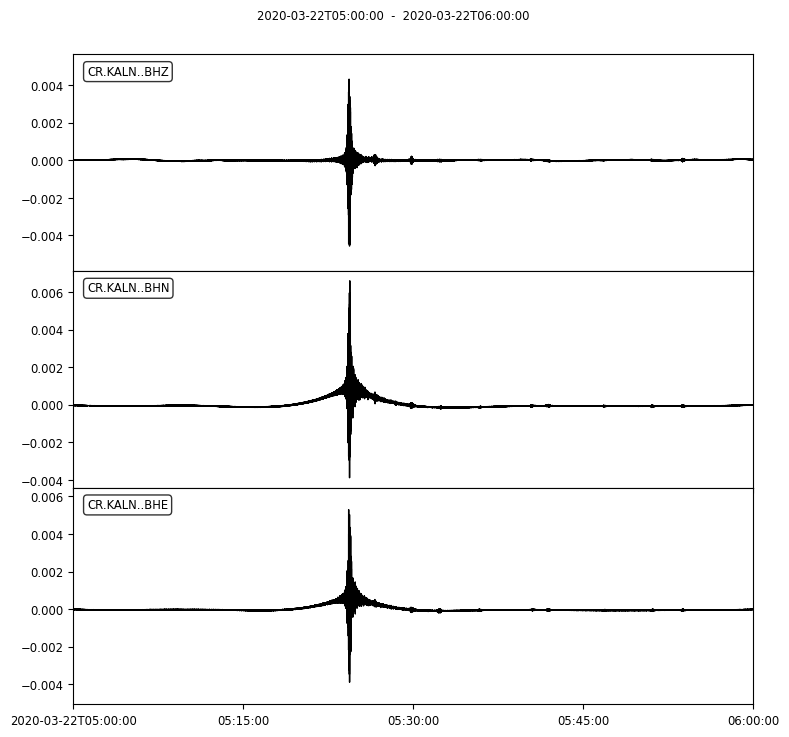

In [12]:
st.plot();

st_real = st.copy()
st_real.remove_response(inventory=inventory)
st_real.plot();

Ovaj zapis ne izgleda dobro! Možemo filtrirati originalni zapis kako bi se uklonile eventualne smetnje. To možemo napraviti korištenjem opcije [`pre_filt`](https://docs.obspy.org/packages/autogen/obspy.core.trace.Trace.remove_response.html#obspy.core.trace.Trace.remove_response). 

```
pre_filt (list or tuple(float, float, float, float)) – Apply a bandpass filter in frequency domain to the data before deconvolution. The list or tuple defines the four corner frequencies (f1, f2, f3, f4) of a cosine taper which is one between f2 and f3 and tapers to zero for f1 < f < f2 and f3 < f < f4.
```

<div class="alert alert-warning rounded-pill rounded-5" style="margin: auto auto 10px auto; text-align: center;">
    <strong>Napomena</strong>: Kod analize digitalnih signala uvijek moramo paziti na Nyquist frekvenciju!
</div>

Za pred-fitriranje ćemo birati takve frekvencije koje su manje od Nyquistove.

Ponovno ćemo kopirati originalni zapis.

In [ ]:
st.plot();

st_real = st.copy()

fn = st_real[0].stats.sampling_rate / 2.

st_real.remove_response(inventory=inventory, pre_filt=(0.01, 0.02, 0.7 * fn, 0.9 * fn))
st_real.plot();

# Zadaci

## Zadatak 1

Učitajte StationXML u datoteci `./data/CR_stations.xml`. Koliko ima postaja?

## Zadatak 2

Koja je od postaja u učitanom StationXML-u najbliža epicentru zagrebačkog potresa ($\phi=45.425^{\circ}$, $\lambda=16.258^{\circ}$). Možete koristiti funkciju [gps2dist_azimuth](https://docs.obspy.org/packages/autogen/obspy.geodetics.base.gps2dist_azimuth.html).